# One Month Test

This notebook runs the monthly experiment loop using the refactored `UATMPC` package. 


In [12]:
from pathlib import Path
import sys
import time
import warnings
import numpy as np
from functools import cached_property
import pandas as pd

warnings.filterwarnings("ignore")

project_root = Path.cwd()
if project_root.name == "UATMPC":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from UATMPC import MPCConfig, Paths, PhysicalParams
from UATMPC.experiment import ExperimentRunner

paths = Paths.from_root(project_root)
config = MPCConfig()

params = PhysicalParams()
# change to the winter setting:
class Building2Params(PhysicalParams):
    @cached_property
    def tau_min(self):
        return np.concatenate([14 * np.ones(8 * 4), 14 * np.ones(14 * 4), 14 * np.ones(6 * 4)])
    @cached_property
    def tau_max(self):
        return np.concatenate([24 * np.ones(8 * 4), 24 * np.ones(14 * 4), 24 * np.ones(6 * 4)])

# params = Building2Params(
#     tau_ref=19,
#     p_hvac_max=20,
# )

runner = ExperimentRunner(paths, config, params).setup()

paths.results_dir.mkdir(parents=True, exist_ok=True)
paths.results_dir

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results')

## Monthly Settings

`candidate_methods` controls which methods are run. One method over one month can already take a long time, so the default follows `final_full.ipynb` and runs `robust` only.

In [13]:
candidate_month = 7
candidate_dates = [(candidate_month, day) for day in range(2, 32)]
# candidate_month = 1
# candidate_dates = [(candidate_month, day) for day in range(2, 22)]
# Available methods:
# "hard_ua_tube", "soft_ua_tube", "standard", "scenario", "perfect", "robust", "dr"
# "soft_tube_ess", "stochastic_tmpc"
candidate_methods = ["soft_ua_tube", "dr", "standard", "scenario", "perfect", "robust", "soft_tube_ess", "stochastic_tmpc"]
# candidate_methods = ["soft_ua_tube", "soft_tube_ess"]
ww = 0.1
resume_from_csv = True
output_csv = paths.results_dir / f"ttone_month_{candidate_month:02d}_{ww*100}_results.csv"
summary_csv = paths.results_dir / f"ttone_month_{candidate_month:02d}_{ww*100}_summary.csv"

{
    "days": len(candidate_dates),
    "date_start": candidate_dates[0],
    "date_end": candidate_dates[-1],
    "methods": candidate_methods,
    "output_csv": output_csv,
}

{'days': 30,
 'date_start': (7, 2),
 'date_end': (7, 31),
 'methods': ['soft_ua_tube',
  'dr',
  'standard',
  'scenario',
  'perfect',
  'robust',
  'soft_tube_ess',
  'stochastic_tmpc'],
 'output_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/ttone_month_07_10.0_results.csv')}

In [14]:
def run_method(date, method):
    if method == "hard_ua_tube":
        return runner.run_ua_tube_day(date, soft=False)
    if method == "soft_ua_tube":
        return runner.run_ua_tube_day(date, soft=True, ww=ww)
    if method == "dr":
        return runner.run_dr_day(date)
    if method == "standard":
        return runner.run_standard_day(date)
    if method == "scenario":
        return runner.run_scenario_day(date)
    if method == "perfect":
        return runner.run_ground_truth_day(date)
    if method == "robust":
        return runner.run_robust_day(date)
    if method == "soft_tube_ess":
        return runner.run_tube_day(date, soft=True, ww=ww, alphas=(0.0, 0.0, 1.0, 0.0))
    if method == "stochastic_tmpc":
        return runner.run_stochastic_tmpc_day(date, ww=ww, alphas=(0.0, 0.0, 1.0, 0.0))
    raise ValueError(f"Unknown method: {method}")


def summarize_result(result, method_name):
    month, day = result["date"]
    return {
        "date_month": month,
        "date_day": day,
        "method": method_name,
        "runtime": result["runtime"],
        "total_cost": result["total_cost"],
        "operational_cost": result["operational_cost"],
        "total_penalty": result["total_penalty"],
    }


## Run Monthly Experiments

The loop writes a checkpoint CSV after every finished day/method pair. If the notebook is interrupted, keep `resume_from_csv = True` and rerun this cell to continue from the saved records.

In [15]:
resume_from_csv = True

if resume_from_csv and output_csv.exists():
    records = pd.read_csv(output_csv).to_dict("records")
else:
    records = []

completed = {
    (int(record["date_month"]), int(record["date_day"]), record["method"])
    for record in records
    if record.get("status") == "ok"
}

for date in candidate_dates:
    print(f"Current date is: {date}")
    for method in candidate_methods:
        key = (date[0], date[1], method)
        if key in completed:
            print(f"  Skip finished method: {method}")
            continue

        print(f"  Current method is: {method}")
        started_at = time.time()
        try:
            result = run_method(date, method)
            record = summarize_result(result, method)
            record.update({"status": "ok", "error": ""})
            completed.add(key)
        except Exception as exc:
            record = {
                "date_month": date[0],
                "date_day": date[1],
                "method": method,
                "runtime": time.time() - started_at,
                "total_cost": None,
                "operational_cost": None,
                "total_penalty": None,
                "status": "failed",
                "error": repr(exc),
            }
            print(f"  Failed: {record['error']}")

        records.append(record)
        results = pd.DataFrame(records)
        results.to_csv(output_csv, index=False)
        # display(results.tail(1))

results = pd.DataFrame(records)
results

Current date is: (7, 2)
  Skip finished method: soft_ua_tube
  Skip finished method: dr
  Skip finished method: standard
  Skip finished method: scenario
  Skip finished method: perfect
  Skip finished method: robust
  Skip finished method: soft_tube_ess
  Skip finished method: stochastic_tmpc
Current date is: (7, 3)
  Skip finished method: soft_ua_tube
  Skip finished method: dr
  Skip finished method: standard
  Skip finished method: scenario
  Skip finished method: perfect
  Skip finished method: robust
  Skip finished method: soft_tube_ess
  Skip finished method: stochastic_tmpc
Current date is: (7, 4)
  Skip finished method: soft_ua_tube
  Skip finished method: dr
  Skip finished method: standard
  Skip finished method: scenario
  Skip finished method: perfect
  Skip finished method: robust
  Skip finished method: soft_tube_ess
  Skip finished method: stochastic_tmpc
Current date is: (7, 5)
  Skip finished method: soft_ua_tube
  Skip finished method: dr
  Skip finished method: sta

,date_month,date_day,method,runtime,total_cost,operational_cost,total_penalty,status,error
0,7,2,soft_ua_tube,139.609421,420.028061,420.028061,0.000000,ok,NaN
1,7,2,dr,167.738938,549.705220,396.043249,153.661970,ok,NaN
2,7,2,standard,57.576157,548.312967,388.618484,159.694483,ok,NaN
3,7,2,scenario,164.478584,545.019201,413.912969,131.106232,ok,NaN
4,7,2,perfect,0.228442,277.772310,277.772310,0.000000,ok,NaN
...,...,...,...,...,...,...,...,...,...
235,7,31,scenario,162.315522,1286.002728,1134.339398,151.663330,ok,NaN
236,7,31,perfect,0.161951,1010.659914,1010.659914,0.000000,ok,NaN
237,7,31,robust,56.826145,1253.485104,1253.485104,0.000000,ok,NaN
238,7,31,soft_tube_ess,87.383350,1257.650958,1237.269307,20.381651,ok,NaN


In [16]:
ok_results = results[results["status"] == "ok"].copy()

monthly_summary = (
    ok_results.groupby("method")
    .agg(
        days=("date_day", "count"),
        total_cost_mean=("total_cost", "mean"),
        total_cost_sum=("total_cost", "sum"),
        operational_cost_mean=("operational_cost", "mean"),
        total_penalty_mean=("total_penalty", "mean"),
        runtime_sum=("runtime", "sum"),
        runtime_mean=("runtime", "mean"),
    )
    .reset_index()
)

monthly_summary.to_csv(summary_csv, index=False)
monthly_summary

,method,days,total_cost_mean,total_cost_sum,operational_cost_mean,total_penalty_mean,runtime_sum,runtime_mean
0,dr,30,1142.676220,34280.286611,929.164353,213.511867,10022.562271,334.085409
1,perfect,30,760.391564,22811.746911,760.391564,0.000000,6.302622,0.210087
2,robust,30,1078.615211,32358.456329,1078.615211,0.000000,1706.579658,56.885989
3,scenario,30,1125.853598,33775.607932,928.571899,197.281699,4936.046175,164.534873
4,soft_tube_ess,30,1081.716185,32451.485536,1059.282946,22.433238,2573.235151,85.774505
5,soft_ua_tube,30,972.630779,29178.923381,972.588434,0.042345,4103.639993,136.788000
6,standard,30,1136.453969,34093.619061,907.116064,229.337904,1723.257368,57.441912
7,stochastic_tmpc,30,1080.318100,32409.543006,1080.265348,0.052752,3488.474448,116.282482


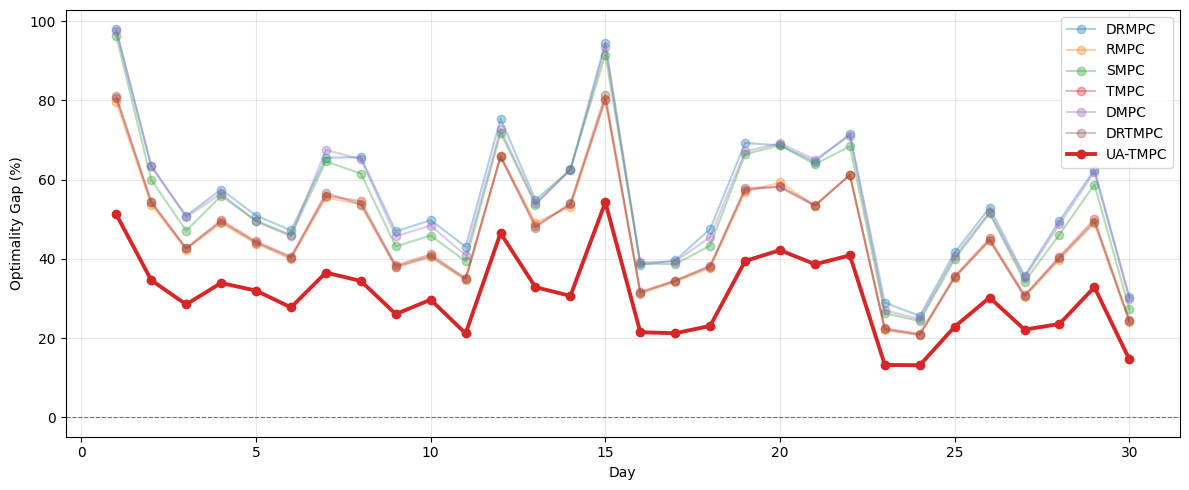

In [17]:
import matplotlib.pyplot as plt

if not ok_results.empty:
    cost_pivot = ok_results.pivot(index="date_day", columns="method", values="total_cost")
    perfect_cost = cost_pivot["perfect"]
    gap_pivot = cost_pivot.sub(perfect_cost, axis=0).div(perfect_cost, axis=0) * 100
    gap_pivot.index = gap_pivot.index - 1

    highlight_method = "soft_ua_tube"
    method_labels = {
        "soft_ua_tube": "UA-TMPC",
        "dr": "DRMPC",
        "robust": "RMPC",
        "scenario": "SMPC",
        "soft_tube_ess": "TMPC",
        "standard": "DMPC",
        "stochastic_tmpc": "DRTMPC",
    }
    gap_methods = [method for method in gap_pivot.columns if method != "perfect" and method != "soft_dr_tube"]
    other_methods = [method for method in gap_methods if method != highlight_method]

    fig, ax = plt.subplots(figsize=(12, 5))
    for method in other_methods:
        ax.plot(
            gap_pivot.index,
            gap_pivot[method],
            marker="o",
            linewidth=1.5,
            alpha=0.35,
            label=method_labels.get(method, method),
        )

    ax.plot(
        gap_pivot.index,
        gap_pivot[highlight_method],
        marker="o",
        color="#D62728",
        linewidth=2.8,
        markersize=6,
        zorder=5,
        label=method_labels.get(highlight_method, highlight_method),
    )

    # ax.set_title(f"Optimality Gap, Month {candidate_month}")
    ax.set_xlabel("Day")
    ax.set_ylabel("Optimality Gap (%)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    figures_dir = paths.root / "UATMPC" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    fig_path = figures_dir / f"Optimality_Gap_Month_{candidate_month}.pdf"
    fig.savefig(fig_path, bbox_inches="tight")
    fig_path

In [18]:
method_labels = {
    "perfect": "Ground Truth",
    "standard": "DMPC",
    "scenario": "SMPC",
    "robust": "RMPC",
    "soft_tube_ess": "TMPC",
    "dr": "DRMPC",
    "stochastic_tmpc": "DRTMPC",
    "soft_ua_tube": "UA-TMPC",
}
method_order = [
    "perfect",
    "standard",
    "scenario",
    "robust",
    "dr",
    "soft_tube_ess",
    "stochastic_tmpc",
    "soft_ua_tube",
]

if not ok_results.empty:
    summary_by_method = ok_results.groupby("method").agg(
        total_cost=("total_cost", "mean"),
        operational_cost=("operational_cost", "mean"),
        penalty_cost=("total_penalty", "mean"),
    )
    perfect_total = summary_by_method.loc["perfect", "total_cost"]

    comparison_rows = []
    for method in method_order:
        if method not in summary_by_method.index:
            continue
        row = summary_by_method.loc[method]
        if method == "perfect":
            gap = "-"
        else:
            gap = f"{(row['total_cost'] - perfect_total) / perfect_total * 100:.2f}%"

        comparison_rows.append(
            {
                "Method": method_labels[method],
                "Total Cost($)": f"{row['total_cost']:.2f}",
                "Operation Cost($)": f"{row['operational_cost']:.2f}",
                "Penalty Cost($)": f"{row['penalty_cost']:.2f}",
                "Optimality Gap(%)": gap,
            }
        )

    comparison_table = pd.DataFrame(comparison_rows)
    comparison_csv = paths.results_dir / f"one_month_{candidate_month:02d}_{ww * 100}_comparison_table.csv"
    comparison_table.to_csv(comparison_csv, index=False)

    print(comparison_table.to_string(index=False))

      Method Total Cost($) Operation Cost($) Penalty Cost($) Optimality Gap(%)
Ground Truth        760.39            760.39            0.00                 -
        DMPC       1136.45            907.12          229.34            49.46%
        SMPC       1125.85            928.57          197.28            48.06%
        RMPC       1078.62           1078.62            0.00            41.85%
       DRMPC       1142.68            929.16          213.51            50.27%
        TMPC       1081.72           1059.28           22.43            42.26%
      DRTMPC       1080.32           1080.27            0.05            42.07%
     UA-TMPC        972.63            972.59            0.04            27.91%


In [10]:
{
    "daily_results_csv": output_csv,
    "summary_csv": summary_csv,
}

{'daily_results_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/ttone_month_01_10.0_results.csv'),
 'summary_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/ttone_month_01_10.0_summary.csv')}

In [11]:
for _, row in monthly_summary.iterrows():
    print(f"{row['method']}: {row['runtime_mean'] / 96:.6f}")

dr: 3.480056
perfect: 0.002188
robust: 0.592562
scenario: 1.713905
soft_tube_ess: 0.893484
soft_ua_tube: 1.424875
standard: 0.598353
stochastic_tmpc: 1.211276
